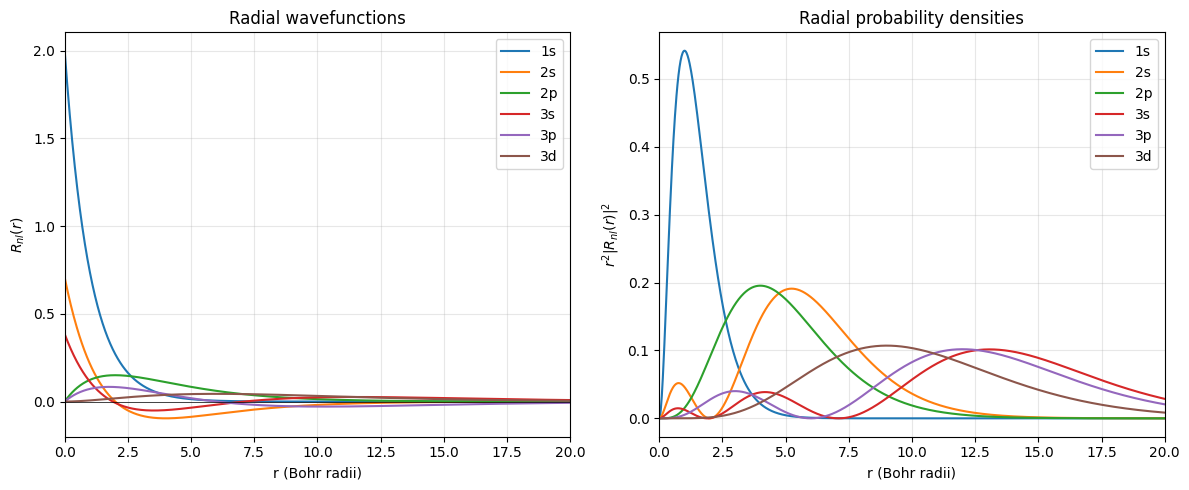

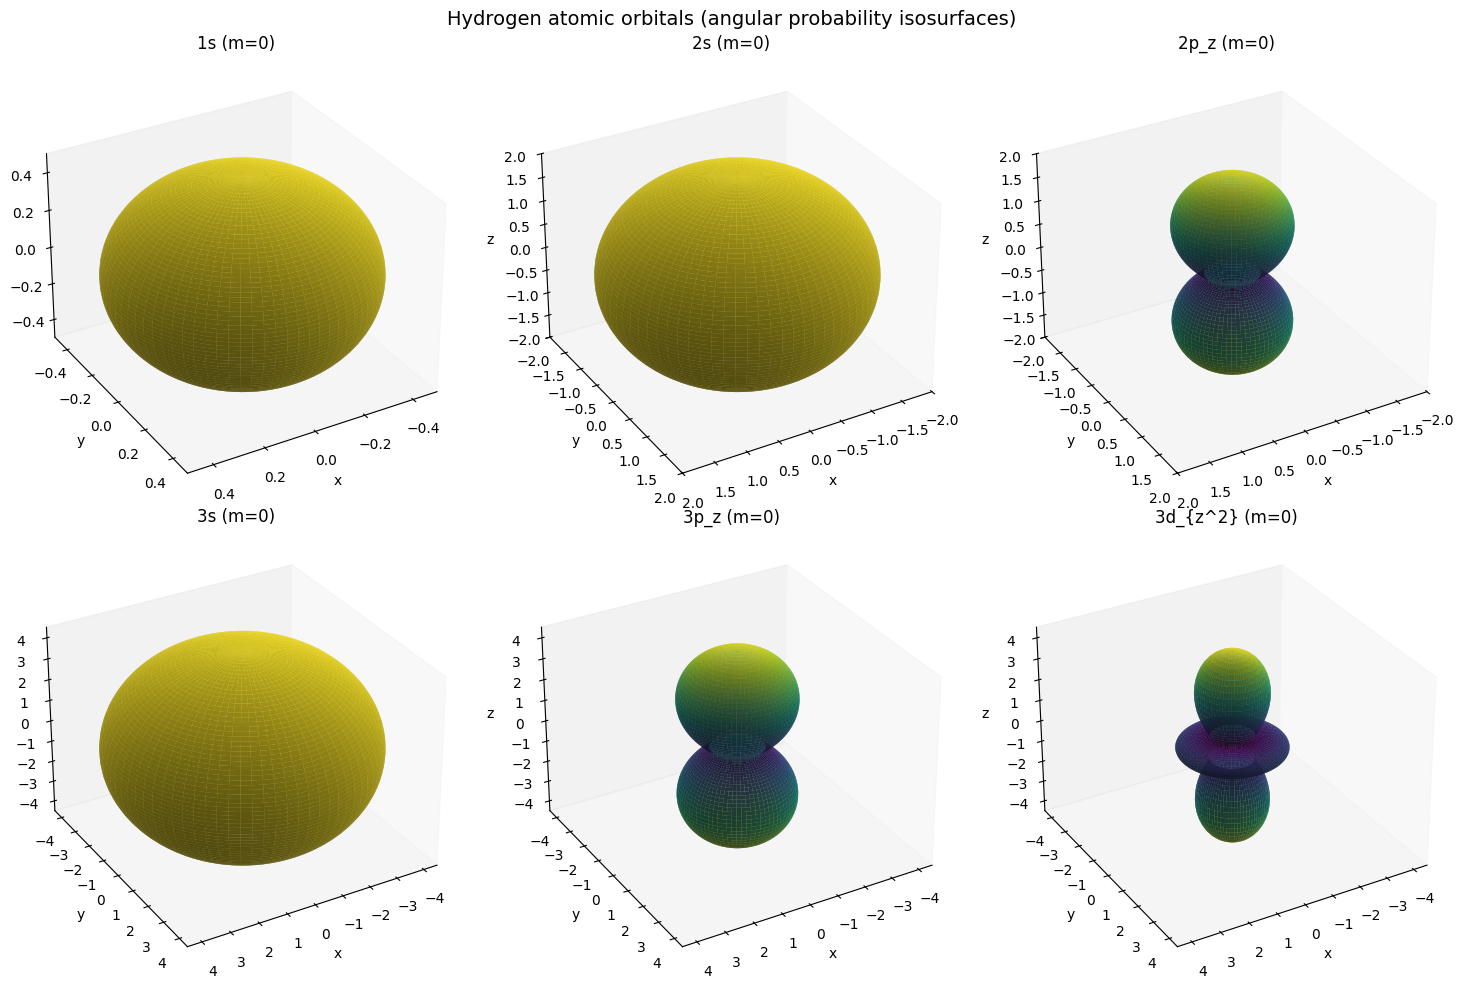

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm_y, factorial, genlaguerre  # fixed imports
from mpl_toolkits.mplot3d import Axes3D

# ---------- Radial wavefunction ----------
def radial_wavefunction(n, l, r):
    """Hydrogen radial wavefunction R_nl(r) in atomic units (a0=1)."""
    prefactor = np.sqrt((2.0/n)**3 * factorial(n-l-1) / (2.0*n * factorial(n+l)))
    rho = 2.0 * r / n
    laguerre = genlaguerre(n-l-1, 2*l+1)(rho)
    return prefactor * (rho**l) * np.exp(-rho/2.0) * laguerre

# Radial grid for 1D plots
r = np.linspace(0, 20, 1000)
states = [(1,0,'1s'), (2,0,'2s'), (2,1,'2p'), (3,0,'3s'), (3,1,'3p'), (3,2,'3d')]

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
for n,l,label in states:
    plt.plot(r, radial_wavefunction(n,l,r), label=label)
plt.xlabel('r (Bohr radii)')
plt.ylabel('$R_{nl}(r)$')
plt.title('Radial wavefunctions')
plt.axhline(0, color='k', lw=0.5)
plt.xlim(0,20)
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
for n,l,label in states:
    R = radial_wavefunction(n,l,r)
    prob = r**2 * R**2
    plt.plot(r, prob, label=label)
plt.xlabel('r (Bohr radii)')
plt.ylabel('$r^2 |R_{nl}(r)|^2$')
plt.title('Radial probability densities')
plt.xlim(0,20)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- 3D visualization of orbitals ----------
def spherical_harmonic_surface(n, l, m=0, resolution=100, scale_factor=1.0):
    """
    Generate a 3D surface for orbital (n,l,m) where the radius is
    proportional to |Y_l^m(θ,φ)|², and then scaled by n² to show size.
    Returns meshgrid of x, y, z and color values (the angular density).
    """
    theta = np.linspace(0, np.pi, resolution)
    phi = np.linspace(0, 2*np.pi, resolution)
    theta, phi = np.meshgrid(theta, phi)
    
    # Use the new sph_harm_y function with order (l, m, theta, phi)
    Y = sph_harm_y(l, m, theta, phi)   # <-- fixed: now uses sph_harm_y
    # Probability density (real)
    angular_prob = np.abs(Y)**2
    
    # Normalize to max = 1 for coloring
    angular_prob = angular_prob / np.max(angular_prob)
    
    # Radius = base scale * n² (size grows with n) * (angular shape)
    base_radius = scale_factor * n**2
    if l == 0:
        r_surface = base_radius * np.ones_like(theta)
    else:
        # Multiply by angular probability to get dumbbell/cloverleaf shape
        # Add a small constant to avoid zero in the lobes
        r_surface = base_radius * (0.2 + 0.8 * angular_prob)
    
    # Convert to Cartesian
    x = r_surface * np.sin(theta) * np.cos(phi)
    y = r_surface * np.sin(theta) * np.sin(phi)
    z = r_surface * np.cos(theta)
    
    return x, y, z, angular_prob

# List of orbitals to visualize: (n, l, m, label)
orbitals_3d = [(1,0,0,'1s'), (2,0,0,'2s'), (2,1,0,'2p_z'),
               (3,0,0,'3s'), (3,1,0,'3p_z'), (3,2,0,'3d_{z^2}')]

fig = plt.figure(figsize=(15, 10))
for idx, (n, l, m, label) in enumerate(orbitals_3d, start=1):
    ax = fig.add_subplot(2, 3, idx, projection='3d')
    x, y, z, color = spherical_harmonic_surface(n, l, m, resolution=80, scale_factor=0.5)
    # Plot surface with face colors given by angular_prob (color map)
    surf = ax.plot_surface(x, y, z, facecolors=plt.cm.viridis(color), 
                           rstride=1, cstride=1, alpha=0.9, linewidth=0, antialiased=True)
    ax.set_title(f'{label} (m={m})', fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    # Set equal aspect ratio (approximate)
    max_range = np.max([np.abs(x).max(), np.abs(y).max(), np.abs(z).max()])
    ax.set_xlim([-max_range, max_range])
    ax.set_ylim([-max_range, max_range])
    ax.set_zlim([-max_range, max_range])
    ax.view_init(elev=30, azim=60)
    ax.grid(False)

plt.suptitle('Hydrogen atomic orbitals (angular probability isosurfaces)', y=0.98, fontsize=14)
plt.tight_layout()
plt.show()